<h1 style="text-align:center; color:red;">ChallengeDay</h1>

In [4]:
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xzf flower_photos.tgz

--2026-03-20 18:14:07--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.141.207, 142.251.2.207, 74.125.137.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.141.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M   112MB/s    in 2.0s    

2026-03-20 18:14:09 (112 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]



In [6]:

# 4. Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os
from scipy.ndimage import rotate
from PIL import Image

%matplotlib inline


In [7]:

# 5. Image Transformations


# Rotation
def rotate_image_30_degrees(image):
    return rotate(image, 30, reshape=False)

# Flip horizontal + vertical
def flip_image(image):
    flipped = np.fliplr(image)
    flipped = np.flipud(flipped)
    return flipped

# Zoom (1.2x)
def zoom_image(image):
    img = Image.fromarray(image)
    width, height = img.size
    new_width = int(width * 1.2)
    new_height = int(height * 1.2)
    zoomed = img.resize((new_width, new_height))
    return np.array(zoomed)

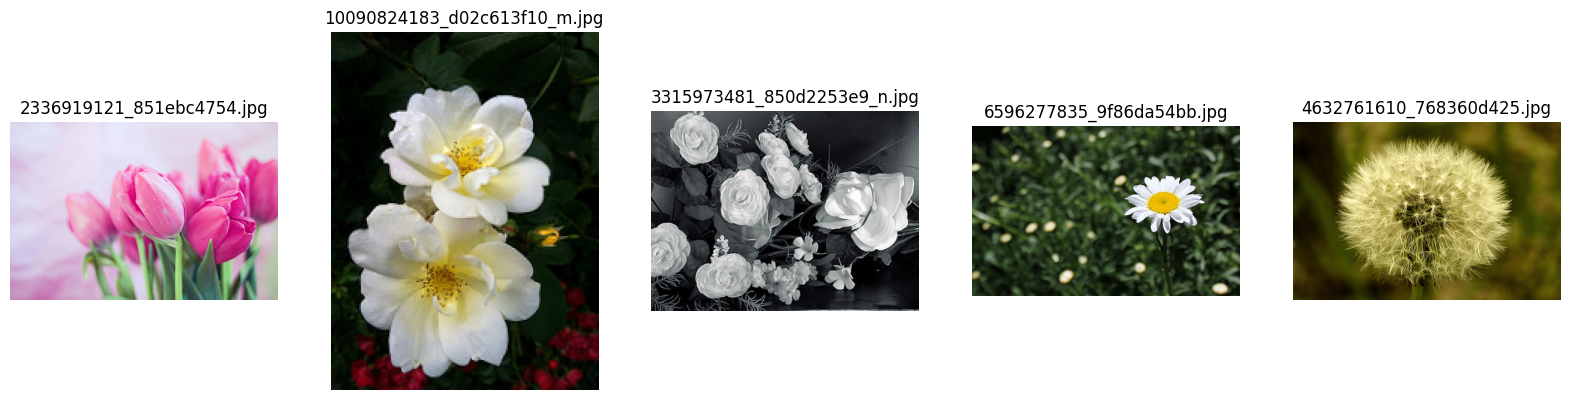

In [9]:
list_img = []
list_names = []

folder = 'flower_photos'

# Récupérer toutes les images dans les sous-dossiers
all_images = []

for subfolder in os.listdir(folder):
    subfolder_path = os.path.join(folder, subfolder)

    if os.path.isdir(subfolder_path):
        for file in os.listdir(subfolder_path):
            image_path = os.path.join(subfolder_path, file)
            all_images.append(image_path)

# Sélection aléatoire
selected_images = random.sample(all_images, 5)

plt.figure(figsize=(20,20))

for i, image_path in enumerate(selected_images):
    img = mpimg.imread(image_path)

    list_img.append(img)
    list_names.append(os.path.basename(image_path))

    ax = plt.subplot(3,5,i+1)
    ax.title.set_text(list_names[i])
    plt.imshow(img)
    plt.axis('off')

In [10]:

# 7. Apply Transformations


rotated_list = []
flipped_list = []
zoomed_list = []

for img in list_img:
    rotated_list.append(rotate_image_30_degrees(img))
    flipped_list.append(flip_image(img))
    zoomed_list.append(zoom_image(img))

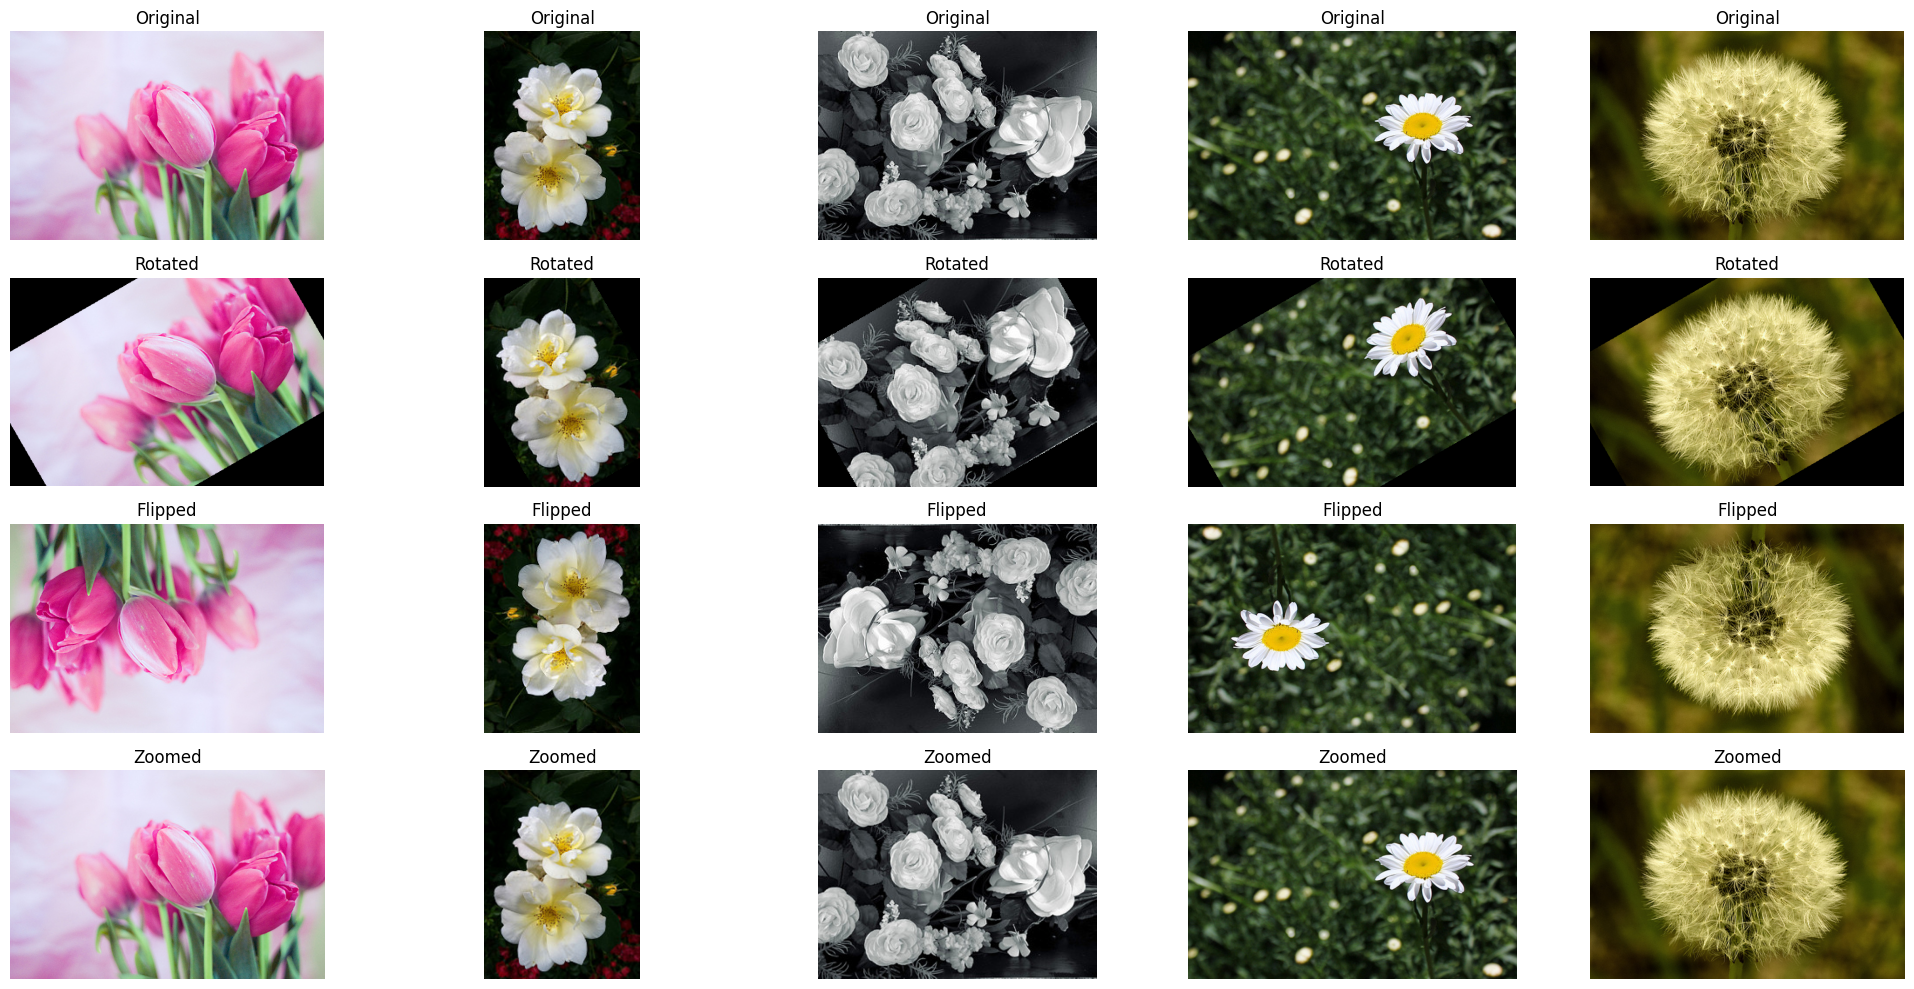

In [11]:

# 8. Display Results


plt.figure(figsize=(20,10))

for i in range(len(list_img)):
    # Original
    ax = plt.subplot(4, len(list_img), i+1)
    plt.imshow(list_img[i])
    ax.set_title("Original")
    plt.axis('off')

    # Rotated
    ax = plt.subplot(4, len(list_img), i+1+len(list_img))
    plt.imshow(rotated_list[i])
    ax.set_title("Rotated")
    plt.axis('off')

    # Flipped
    ax = plt.subplot(4, len(list_img), i+1+2*len(list_img))
    plt.imshow(flipped_list[i])
    ax.set_title("Flipped")
    plt.axis('off')

    # Zoomed
    ax = plt.subplot(4, len(list_img), i+1+3*len(list_img))
    plt.imshow(zoomed_list[i])
    ax.set_title("Zoomed")
    plt.axis('off')

plt.tight_layout()
plt.show()